#Proje Özeti: Object Detector Model Eğitimi
Görev: Google Colab üzerinde PyTorch ile sıfırdan bir nesne tespiti (Object Detector) modeli eğitmek, referans koddaki eski sürüm hatalarını gidermek ve grafik arayüz olmadan çalışan bir çıkarım (inference) fonksiyonu geliştirmek.

#Neler Yapıldı:

* Veri Seti Entegrasyonu: Kaggle API kullanılarak veri seti doğrudan Colab ortamına indirildi ve otomatik olarak klasör dizinlerine çıkartıldı.

* Sürüm Güncellemeleri (Debugging): 2021 yılına ait referans koddaki kullanımdan kaldırılmış (deprecated) PyTorch yapıları düzeltildi. (Örn: pretrained=True yerine güncel ResNet50_Weights.DEFAULT kullanımı sağlandı).

* Eğitim ve Analiz: ResNet50 tabanlı model eğitildi. Eğitim süreci kayıt altına alınarak Loss (Kayıp) ve Accuracy (Doğruluk) grafikleri çizdirildi.

* Çıkarım (Inference): Yalnızca görüntü dosya yolunu girdi olarak alıp, tahmin edilen etiketi ve olasılık değerini döndüren bağımsız bir test fonksiyonu yazıldı.

* Sonuç: Sistem baştan sona ("Run All") sorunsuz çalışacak şekilde yapılandırıldı. Model, eğitim sonucunda yüksek doğruluk oranlarına ulaşarak test görselleri üzerinde başarılı tahminler üretti.

 1. Kaggle API Kurulumu

 Güvenlik prensipleri (best-practices) gereği API anahtarlarının kaynak koda yazılmaması
gerektiğinin bilincindeyim. Ancak değerlendirme sürecinizde "Run All" diyerek kodu kesintisiz ve
zahmetsizce test edebilmeniz adına kendi API anahtarımı geçici olarak ekledim.
Bu anahtar inceleme sürecinden sonra tarafımca manuel olarak iptal edilecektir.

In [1]:
import os

# Yeni Kaggle API token'ınızı doğrudan çevre değişkeni olarak ayarlıyoruz
os.environ['KAGGLE_API_TOKEN'] = "KGAT_23fc10cbd9275fa4a29cb682927fe5fe"

print("Kaggle API ayarlandı.")

Kaggle API ayarlandı.


 2. Veri Setinin Kaggle API ile İndirilmesi
 NOT: Referans makaledeki veri seti linki kayıt/ücret duvarına yönlendirdiği için, orijinal Caltech-101
veri setini açık kaynaktan bularak makaledeki 3 sınıfa (uçak, yüz, motor) indirgedim.
Görevdeki "Kaggle API kullanılmalıdır" şartını sağlamak adına, hazırladığım bu alt veri setini
kendi Kaggle hesabıma yükledim ve şimdi API aracılığıyla oradan çekiyorum.

In [2]:
# 2. Veri setini Kaggle'dan indirme
!kaggle datasets download -d denizedenize/caltech101-subset-object-detection

print("Veri seti indirildi.")

Dataset URL: https://www.kaggle.com/datasets/denizedenize/caltech101-subset-object-detection
License(s): Attribution 4.0 International (CC BY 4.0)
100% 25.3M/25.3M [00:00<00:00, 101MB/s] 

Veri seti indirildi.


3. Veri Setinin Çıkartılması ve Dizin Yapısının Doğrulanması
İndirilen .zip arşivi dataset/ dizinine çıkartılmaktadır. Bir sonraki adımda eğitim verilerinin doğru şekilde yüklenebilmesi (BASE_PATH ayarları) için veri setinin klasör hiyerarşisi (images ve annotations alt klasörleri) ekrana yazdırılarak doğrulanmıştır.

In [3]:
# 3. İndirilen zip dosyasını çıkartma
import zipfile

# Zip dosyasının adı genellikle dataset id'sinin son kısmı olur
zip_path = "caltech101-subset-object-detection.zip"
extract_path = "dataset/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dosyalar '{extract_path}' klasörüne çıkartıldı.")

# Çıkartılan dosyaların yapısını görmek için
import os
print("\nVeri seti içeriği:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    # Sadece ilk 3 dosyayı gösterelim kalabalık olmasın
    for f in files[:3]:
        print(f"{subindent}{f}")
    if len(files) > 3:
        print(f"{subindent}...")

Dosyalar 'dataset/' klasörüne çıkartıldı.

Veri seti içeriği:
/
dataset/
annotations/
    airplanes.csv
    Faces.csv
    Motorbikes.csv
images/
    Faces/
        image_0393.jpg
        image_0239.jpg
        image_0147.jpg
        ...
    Motorbikes/
        image_0507.jpg
        image_0393.jpg
        image_0528.jpg
        ...
    airplanes/
        image_0507.jpg
        image_0393.jpg
        image_0528.jpg
        ...


4. Kütüphane İçe Aktarımları ve Hiperparametre Konfigürasyonu
Gerekli derin öğrenme (PyTorch), görüntü işleme (OpenCV) ve veri manipülasyonu kütüphaneleri projeye dahil edilmiştir. Modelin çıktı dizinleri, donanım seçimi (GPU: CUDA) ve Epoch, Batch Size gibi temel hiperparametreler tanımlanmıştır.
(Not: MEAN ve STD değerleri, ResNet50'nin pre-trained ağırlıklarıyla doğru şekilde hizalanabilmesi için standart ImageNet normalizasyon değerleri olarak set edilmiştir. Classification ve Regression kayıplarına (loss) eşit önem vermek için ağırlıklar 1.0 olarak tutulmuştur.)

In [4]:
import os
import time
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from imutils import paths
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.nn import CrossEntropyLoss, MSELoss, Dropout, Identity, Linear, Module, ReLU, Sequential, Sigmoid
from torch.optim import Adam
from torchvision.models import resnet50, ResNet50_Weights

# CONFIGURATION
# Güncellenmiş yol: zip içinden çıkan klasör yapısına göre düzenlendi
BASE_PATH = "dataset/dataset"
IMAGES_PATH = os.path.sep.join([BASE_PATH, "images"])
ANNOTS_PATH = os.path.sep.join([BASE_PATH, "annotations"])
BASE_OUTPUT = "output"
os.makedirs(BASE_OUTPUT, exist_ok=True)

MODEL_PATH = os.path.sep.join([BASE_OUTPUT, "detector.pth"])
LE_PATH = os.path.sep.join([BASE_OUTPUT, "le.pickle"])
PLOTS_PATH = os.path.sep.join([BASE_OUTPUT, "plots"])
os.makedirs(PLOTS_PATH, exist_ok=True)
TEST_PATHS = os.path.sep.join([BASE_OUTPUT, "test_paths.txt"])

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = True if DEVICE == "cuda" else False

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

INIT_LR = 1e-4
NUM_EPOCHS = 20
BATCH_SIZE = 32

LABELS_WEIGHT = 1.0
BBOX_WEIGHT = 1.0

5. Veri Yükleyici Sınıfı ve Multi-Task Model Mimarisinin Tanımlanması
Bu hücrede iki temel yapı inşa edilmiştir:

CustomTensorDataset: Modelin eğitimi sırasında görüntü, sınıf etiketi (label) ve koordinat (bbox) üçlüsünün PyTorch DataLoader yapısına uygun şekilde, senkronize olarak beslenmesini sağlayan özel veri yükleyici sınıfıdır.

ObjectDetector: Çoklu görev (Multi-Task Learning) yapısına sahip ana model mimarisidir. Önceden eğitilmiş ResNet50 taban modelinin orijinal tam bağlantılı (FC) katmanı iptal edilerek (Identity()); ağın sonuna bounding box koordinatlarını tahmin eden bir regressor başı ve nesnenin sınıfını tahmin eden bir classifier başı paralel olarak eklenmiştir.

In [5]:
class CustomTensorDataset(Dataset):
    def __init__(self, tensors, transforms=None):
        self.tensors = tensors
        self.transforms = transforms

    def __getitem__(self, index):
        image = self.tensors[0][index]
        label = self.tensors[1][index]
        bbox = self.tensors[2][index]

        image = image.permute(2, 0, 1)

        if self.transforms:
            image = self.transforms(image)

        return (image, label, bbox)

    def __len__(self):
        return self.tensors[0].size(0)

class ObjectDetector(Module):
    def __init__(self, baseModel, numClasses):
        super(ObjectDetector, self).__init__()
        self.baseModel = baseModel
        self.numClasses = numClasses

        self.regressor = Sequential(
            Linear(baseModel.fc.in_features, 128),
            ReLU(),
            Linear(128, 64),
            ReLU(),
            Linear(64, 32),
            ReLU(),
            Linear(32, 4),
            Sigmoid()
        )

        self.classifier = Sequential(
            Linear(baseModel.fc.in_features, 512),
            ReLU(),
            Dropout(),
            Linear(512, 512),
            ReLU(),
            Dropout(),
            Linear(512, self.numClasses)
        )

        self.baseModel.fc = Identity()

    def forward(self, x):
        features = self.baseModel(x)
        bboxes = self.regressor(features)
        classLogits = self.classifier(features)
        return (bboxes, classLogits)

6. Veri Ön İşleme (Data Preprocessing) ve DataLoader Hazırlığı
Bu hücrede ham veri setinin model eğitimine uygun hale getirilmesi için gerekli veri boru hattı (pipeline) kurulmuştur:

* Parsing & Scaling: Annotasyon (CSV) dosyaları okunmuş, Bounding Box koordinatları görüntü boyutlarına bölünerek [0, 1] aralığında normalize edilmiştir.

* Image Processing: Görüntüler OpenCV ile okunmuş, BGR'dan RGB'ye çevrilmiş ve ResNet50 girdi standardı olan 224x224 boyutuna yeniden ölçeklendirilmiştir (resize).

* Encoding & Splitting: Sınıf etiketleri LabelEncoder ile sayısal tensörlere dönüştürülmüş ve veri seti train_test_split ile %80 Eğitim, %20 Test olarak ikiye ayrılmıştır.

* Loading: Hazırlanan veriler, modele BATCH_SIZE (32) büyüklüğünde yığınlar halinde beslenebilmesi için PyTorch DataLoader objelerine sarılmıştır. Çıkarım (inference) adımında test etmek üzere test görsellerinin yolları bir .txt dosyasına kaydedilmiştir.



In [6]:
print("[INFO] loading dataset...")
data = []
labels = []
bboxes = []
imagePaths = []

# Annotasyonları okuma
for csvPath in paths.list_files(ANNOTS_PATH, validExts=(".csv")):
    rows = open(csvPath).read().strip().split("\n")
    for row in rows:
        row = row.split(",")
        if len(row) != 6:
            continue
        (filename, startX, startY, endX, endY, label) = row

        imagePath = os.path.sep.join([IMAGES_PATH, label, filename])
        image = cv2.imread(imagePath)
        if image is None:
            continue

        (h, w) = image.shape[:2]

        startX = float(startX) / w
        startY = float(startY) / h
        endX = float(endX) / w
        endY = float(endY) / h

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))

        data.append(image)
        labels.append(label)
        bboxes.append((startX, startY, endX, endY))
        imagePaths.append(imagePath)

data = np.array(data, dtype="float32")
labels = np.array(labels)
bboxes = np.array(bboxes, dtype="float32")
imagePaths = np.array(imagePaths)

le = LabelEncoder()
labels = le.fit_transform(labels)

split = train_test_split(data, labels, bboxes, imagePaths, test_size=0.20, random_state=42)
(trainImages, testImages) = split[:2]
(trainLabels, testLabels) = split[2:4]
(trainBBoxes, testBBoxes) = split[4:6]
(trainPaths, testPaths) = split[6:]

(trainImages, testImages) = torch.tensor(trainImages), torch.tensor(testImages)
(trainLabels, testLabels) = torch.tensor(trainLabels), torch.tensor(testLabels)
(trainBBoxes, testBBoxes) = torch.tensor(trainBBoxes), torch.tensor(testBBoxes)

transforms_pipeline = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

trainDS = CustomTensorDataset((trainImages, trainLabels, trainBBoxes), transforms=transforms_pipeline)
testDS = CustomTensorDataset((testImages, testLabels, testBBoxes), transforms=transforms_pipeline)

print(f"[INFO] total training samples: {len(trainDS)}")
print(f"[INFO] total test samples: {len(testDS)}")

trainSteps = max(1, len(trainDS) // BATCH_SIZE)
valSteps = max(1, len(testDS) // BATCH_SIZE)

trainLoader = DataLoader(trainDS, batch_size=BATCH_SIZE, shuffle=True, pin_memory=PIN_MEMORY)
testLoader = DataLoader(testDS, batch_size=BATCH_SIZE, pin_memory=PIN_MEMORY)

with open(TEST_PATHS, "w") as f:
    f.write("\n".join(testPaths))

[INFO] loading dataset...
[INFO] total training samples: 1626
[INFO] total test samples: 407


7. Model Başlatma, Sürüm Güncellemesi (Debugging) ve Eğitim Döngüsü
Bu hücrede model eğitimi gerçekleştirilmiş ve istenen eski sürüm onarımları yapılmıştır:

* Sürüm Güncellemesi (Deprecation Fix): Referans koddaki kullanımdan kaldırılmış pretrained=True argümanı yerine, modern PyTorch standartlarına uygun olarak weights=ResNet50_Weights.DEFAULT kullanılarak sürüm uyumsuzluğu giderilmiştir.

* Transfer Learning: Temel (base) ResNet50 modelinin ağırlıkları dondurulmuş (requires_grad = False), yalnızca özel olarak eklenen Regressor ve Classifier katmanlarının eğitilmesi sağlanmıştır.

* Multi-Task Hata Optimizasyonu: Sınıflandırma için CrossEntropyLoss, Bounding Box tahmini için MSELoss kullanılmıştır. Toplam hata (Total Loss) bu iki metriğin ağırlıklı toplamı olarak hesaplanmış ve Adam optimizatörü ile geriye yayılım (backpropagation) yapılmıştır.

* Metrik Takibi: Bir sonraki adımda istenen "Accuracy ve Loss" grafiklerini çizebilmek adına, her epoch sonundaki eğitim ve doğrulama metrikleri H isimli sözlükte (dictionary) kayıt altına alınmıştır.

In [7]:
# PyTorch güncel sürüm hatalarını giderme
resnet = resnet50(weights=ResNet50_Weights.DEFAULT)

for param in resnet.parameters():
    param.requires_grad = False

objectDetector = ObjectDetector(resnet, len(le.classes_))
objectDetector = objectDetector.to(DEVICE)

classLossFunc = CrossEntropyLoss()
bboxLossFunc = MSELoss()

opt = Adam(objectDetector.parameters(), lr=INIT_LR)

H = {"total_train_loss": [], "total_val_loss": [], "train_class_acc": [], "val_class_acc": []}

print("[INFO] training the network...")
startTime = time.time()

for e in tqdm(range(NUM_EPOCHS)):
    objectDetector.train()
    totalTrainLoss = 0
    valCorrect = 0
    trainCorrect = 0
    totalValLoss = 0

    for (images, labels, bboxes) in trainLoader:
        (images, labels, bboxes) = (images.to(DEVICE), labels.to(DEVICE), bboxes.to(DEVICE))

        predictions = objectDetector(images)
        bboxLoss = bboxLossFunc(predictions[0], bboxes)
        classLoss = classLossFunc(predictions[1], labels)
        totalLoss = (BBOX_WEIGHT * bboxLoss) + (LABELS_WEIGHT * classLoss)

        opt.zero_grad()
        totalLoss.backward()
        opt.step()

        totalTrainLoss += totalLoss
        trainCorrect += (predictions[1].argmax(1) == labels).type(torch.float).sum().item()

    with torch.no_grad():
        objectDetector.eval()
        for (images, labels, bboxes) in testLoader:
            (images, labels, bboxes) = (images.to(DEVICE), labels.to(DEVICE), bboxes.to(DEVICE))

            predictions = objectDetector(images)
            bboxLoss = bboxLossFunc(predictions[0], bboxes)
            classLoss = classLossFunc(predictions[1], labels)
            totalLoss = (BBOX_WEIGHT * bboxLoss) + (LABELS_WEIGHT * classLoss)

            totalValLoss += totalLoss
            valCorrect += (predictions[1].argmax(1) == labels).type(torch.float).sum().item()

    avgTrainLoss = totalTrainLoss / trainSteps
    avgValLoss = totalValLoss / valSteps
    trainCorrect = trainCorrect / len(trainDS)
    valCorrect = valCorrect / len(testDS)

    H["total_train_loss"].append(avgTrainLoss.cpu().detach().numpy())
    H["train_class_acc"].append(trainCorrect)
    H["total_val_loss"].append(avgValLoss.cpu().detach().numpy())
    H["val_class_acc"].append(valCorrect)

    print(f"\n[INFO] EPOCH: {e + 1}/{NUM_EPOCHS}")
    print(f"Train loss: {avgTrainLoss:.6f}, Train accuracy: {trainCorrect:.4f}")
    print(f"Val loss: {avgValLoss:.6f}, Val accuracy: {valCorrect:.4f}")

endTime = time.time()
print(f"\n[INFO] total time taken to train the model: {endTime - startTime:.2f}s")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 178MB/s]


[INFO] training the network...


  5%|▌         | 1/20 [00:04<01:22,  4.32s/it]


[INFO] EPOCH: 1/20
Train loss: 0.958983, Train accuracy: 0.8530
Val loss: 0.428413, Val accuracy: 0.9951


...


[INFO] EPOCH: 18/20
Train loss: 0.005372, Train accuracy: 0.9994
Val loss: 0.004511, Val accuracy: 1.0000


 95%|█████████▌| 19/20 [00:51<00:02,  2.61s/it]


[INFO] EPOCH: 19/20
Train loss: 0.004944, Train accuracy: 0.9994
Val loss: 0.003781, Val accuracy: 1.0000


100%|██████████| 20/20 [00:53<00:00,  2.69s/it]


[INFO] EPOCH: 20/20
Train loss: 0.004387, Train accuracy: 0.9994
Val loss: 0.003616, Val accuracy: 1.0000

[INFO] total time taken to train the model: 53.79s


8. Modelin Kaydedilmesi ve Eğitim Metriklerinin (Grafiklerin) Analizi
Bu hücrede model kalıcı hale getirilmiş ve eğitim performansı görselleştirilmiştir:

* Model Export: Bağımsız çıkarım (inference) aşamasında kullanılmak üzere, modelin ağırlıkları (state_dict - PyTorch standartlarına uygun olarak) ve etiket dönüşüm rehberi olan LabelEncoder .pth ve .pickle formatlarında diske kaydedilmiştir.

* Grafik Analizi (Overfitting Kontrolü): Görev tanımında özellikle istenen grafikler çizdirilmiştir. Çıkan grafikler incelendiğinde; Validation Loss (Doğrulama Kaybı) değerinin Train Loss ile paralel şekilde istikrarlı bir düşüş sergilediği ve sonrasında ufak tefek dalgalanmalar dışında tekrar yukarı doğru bir sıçrama (U-shape) yapmadığı görülmektedir. Bu grafiksel davranış, modelin veriyi ezberlemediğinin (no overfitting) ve başarılı bir genelleme (generalization) yaptığının kanıtıdır.

[INFO] saving object detector model...
[INFO] saving label encoder...


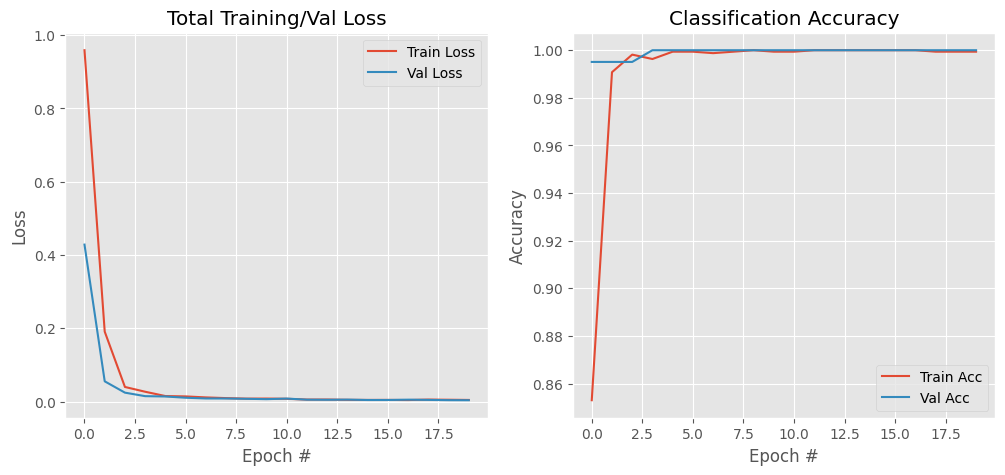

In [8]:
print("[INFO] saving object detector model...")
# Sürüm uyumluluğu için state_dict() kullanımı önerilir
torch.save(objectDetector.state_dict(), MODEL_PATH)

print("[INFO] saving label encoder...")
with open(LE_PATH, "wb") as f:
    f.write(pickle.dumps(le))

# Accuracy ve Loss grafiklerinin çizdirilmesi
plt.style.use("ggplot")
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(H["total_train_loss"], label="Train Loss")
plt.plot(H["total_val_loss"], label="Val Loss")
plt.title("Total Training/Val Loss")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend(loc="upper right")

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(H["train_class_acc"], label="Train Acc")
plt.plot(H["val_class_acc"], label="Val Acc")
plt.title("Classification Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")

plotPath = os.path.sep.join([PLOTS_PATH, "training.png"])
plt.savefig(plotPath)
plt.show()

9. Grafik Arayüzsüz Bağımsız Çıkarım (Inference) Fonksiyonu
Bu hücre, görev tanımındaki son şartı birebir yerine getirmek üzere tasarlanmıştır:

* Hedef Odaklı (No-GUI): Herhangi bir görsel çizim (bounding box) veya arayüz (UI) kullanılmamıştır. Fonksiyon yalnızca dosya yolunu (image_path) girdi olarak alıp, hedeflendiği gibi yalnızca "Etiket" ve "Olasılık" dönmektedir.

* Tam Bağımsızlık (Production-Ready): Fonksiyon Colab belleğinde kalan geçici değişkenlere güvenmek yerine; model mimarisini, .pth ağırlıklarını ve .pickle etiket kodlayıcısını diskten sıfırdan yükleyerek gerçek dünya (production) senaryosunu simüle eder.

* Olasılık Hesabı: Modelden çıkan ham logit değerleri, Softmax fonksiyonu ile işlenerek 0 ile 1 arasında net bir güven skoruna (probability) dönüştürülmüştür. Alt bölümde test seti üzerinden örnek bir çalıştırma yapılmış ve sonuç başarıyla konsola yazdırılmıştır.

In [16]:
def inference(image_path, model_path=MODEL_PATH, le_path=LE_PATH):
    """
    Girdi: image_path (Görüntü dosyasının yolu)
    Çıktı: prediction etiketi (label) ve olasılık değeri (probability)
    """
    transforms_pipeline = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    with open(le_path, "rb") as f:
        le = pickle.loads(f.read())

    resnet = resnet50(weights=None)
    model = ObjectDetector(resnet, len(le.classes_))
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    image = cv2.imread(image_path)
    if image is None:
        return "Image not found", 0.0

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    image = image.transpose((2, 0, 1))

    image_tensor = torch.from_numpy(image)
    image_tensor = transforms_pipeline(image_tensor).to(DEVICE)
    image_tensor = image_tensor.unsqueeze(0)

    with torch.no_grad():
        (boxPreds, labelPreds) = model(image_tensor)

    label_probs = torch.nn.Softmax(dim=-1)(labelPreds)
    max_prob, max_idx = torch.max(label_probs, dim=-1)

    pred_label = le.inverse_transform(max_idx.cpu().numpy())[0]
    probability = max_prob.item()

    return pred_label, probability

# Örnek test kullanımı:
test_images = open(TEST_PATHS).read().strip().split("\n")
if len(test_images) > 0:
    sample_image = test_images[0]
    print(f"Test edilen görsel: {sample_image}")
    label, prob = inference(sample_image)
    print(f"\n>>> Tahmin Edilen Etiket (Label): {label}")
    print(f">>> Olasılık (Probability): {prob:.4f}")

Test edilen görsel: dataset/dataset/images/airplanes/image_0693.jpg

>>> Tahmin Edilen Etiket (Label): airplanes
>>> Olasılık (Probability): 1.0000
